In [1]:
import json
from pathlib import Path

import altair as alt
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


In [2]:
data_dir = Path("../data/MC1_release")
data_path = data_dir / "MC1_graph.json"

with open(data_path) as file:
    data = json.load(file)

G = nx.node_link_graph(data,
                       edges='links')
print(G)

MultiDiGraph with 17412 nodes and 37857 edges


The graph has been loaded correctly.

In [3]:
G.nodes.data()[0]

{'Node Type': 'Song',
 'name': 'Breaking These Chains',
 'single': True,
 'release_date': '2017',
 'genre': 'Oceanus Folk',
 'notable': True}

In [4]:
G.edges(0, data=True)

OutMultiEdgeDataView([(0, 1841, {'Edge Type': 'InterpolatesFrom'}), (0, 4, {'Edge Type': 'RecordedBy'})])

## Analysis of edges

In [5]:
list(nx.selfloop_edges(G, data=True))

[(4430, 4430, {'Edge Type': 'CoverOf'})]

In [6]:
G.nodes(data=True)[4430]

{'Node Type': 'Album',
 'name': 'Whispers of the Orange Grove',
 'release_date': '2017',
 'genre': 'Jazz Surf Rock',
 'notable': True}

There is a single self loop in the graph. This album is annotated as being a cover of itself. This is probably a data quality issue, since this data is crowdsourced.

### Analysis of edges types

In [7]:
edges = []
for source, target, data in G.edges(data=True):
    edges.append({
        'source_type': G.nodes[source]['Node Type'],
        'edge_type': data['Edge Type'],
        'target_type': G.nodes[target]['Node Type'],
    })

edges_df = pd.DataFrame(edges)
edges_df.head()

,source_type,edge_type,target_type
0,Song,InterpolatesFrom,Song
1,Song,RecordedBy,RecordLabel
2,Person,PerformerOf,Song
3,Person,ComposerOf,Song
4,Person,PerformerOf,Song


In [8]:
edge_type_counts = edges_df.edge_type.value_counts().reset_index()

Since altair can handle only so many data, we preaggreagate the dataframe. The recurring combinations of source type, edge type and target type are much fewer than the number of edges of our graph.

In [9]:
counts = edges_df.groupby(['source_type', 'edge_type', 'target_type']).size().reset_index()
counts['count'] = counts[0]
counts = counts.drop(0, axis=1)
print(f"Original dataset: {edges_df.shape}. Aggregated dataset: {counts.shape}")

Original dataset: (37857, 3). Aggregated dataset: (61, 4)


In [10]:
counts.head()

,source_type,edge_type,target_type,count
0,Album,CoverOf,Album,53
1,Album,CoverOf,Song,253
2,Album,DirectlySamples,Album,23
3,Album,DirectlySamples,Song,94
4,Album,DistributedBy,RecordLabel,641


In [11]:
alpha = .5
select = alt.selection_point(encodings=['y'], name='select', on='click')

edges_chart = alt.Chart(counts).mark_bar().encode(
    x=alt.X('sum(count):Q').title('# of links'),
    y=alt.Y('edge_type:N', sort='-x').title('Link type'),
    fillOpacity=alt.when(select).then(alt.value(1)).otherwise(alt.value(alpha)),
    tooltip='sum(count):Q',
).add_params(select).properties(
    width=300,
    height=300,
    title=alt.Title(
        "Source and target type recurring in graph links",
        subtitle="Select a type of link in order to filter the results",
        anchor="start",
        orient="bottom",
    ),
)

sources = alt.Chart(counts).mark_bar().encode(
    x=alt.X('sum(count):Q').title('# of links'),
    y=alt.Y('source_type:N').sort('-x').title('Source'),
    color=alt.Color('source_type:N', legend=None),
    tooltip='sum(count):Q',
).transform_filter(
    select,
).properties(
    width=300,
    height=125,
)

targets = alt.Chart(counts).mark_bar().encode(
    x=alt.X('sum(count):Q').title('# of links'),
    y=alt.Y('target_type:N').sort('-x').title('Target'),
    color=alt.Color('target_type:N', legend=None),
    tooltip='sum(count):Q',
).transform_filter(
    select,
).properties(
    width=300,
    height=125,
)


edges_chart | (sources
         & targets)

alt.HConcatChart(...)

In [12]:
source_dim = go.parcats.Dimension(
    values=edges_df.source_type,
    label="Source type",
)

edge_dim = go.parcats.Dimension(
    values=edges_df.edge_type,
    label="Link Type",
)

target_dim = go.parcats.Dimension(
    values=edges_df.target_type,
    label='Target type',
)

In [13]:
colorscale = dict(zip(edges_df.source_type.unique(), px.colors.qualitative.D3))
colorscale

{'Song': '#1F77B4',
 'Person': '#FF7F0E',
 'Album': '#2CA02C',
 'MusicalGroup': '#D62728',
 'RecordLabel': '#9467BD'}

In [14]:
edges_df['source_color'] = edges_df.source_type.map(colorscale)
edges_df['target_color'] = edges_df.target_type.map(colorscale)

In [15]:
from dash import Dash, Input, Output, callback, dcc, html


In [16]:
app1 = Dash()



app1.layout = [
    html.Label('Color:'),
    dcc.RadioItems(options=['source', 'target', 'none'], value='source', inline=True, id='radio'),
    dcc.Graph(id='graph'),
    ]

@callback(
    Output(component_id='graph', component_property='figure'),
    Input(component_id='radio', component_property='value'),
)
def update_graph(value):
    color = None if value == 'none' else edges_df[f'{value}_color']
    fig = go.Figure(
    data=[
        go.Parcats(
            dimensions=[source_dim, edge_dim, target_dim],
            line={'color': color,
                  'shape': 'hspline'},
        ),
    ],
)
    return fig

if __name__ == '__main__':
    app1.run(port='8052')

In [17]:
app2 = Dash()

app2.layout = [
    html.Label('Color:'),
    dcc.RadioItems(options=['source', 'target', 'none'], value='source', inline=True, id='radio'),
    dcc.Dropdown(options=edges_df.edge_type.unique(), id='dropdown'),
    dcc.Graph(id='graph'),
    ]

@callback(
    Output(component_id='graph', component_property='figure'),
    Input(component_id='radio', component_property='value'),
    Input(component_id='dropdown', component_property='value'),
)
def update_graph(v1, v2):
    filtered_df = edges_df[edges_df.edge_type == v2] if v2 else edges_df

    source_dim = go.parcats.Dimension(
    values=filtered_df.source_type,
    label="Source type",
    )

    target_dim = go.parcats.Dimension(
        values=filtered_df.target_type,
        label='Target type',
    )
    color = None if v1 == 'none' else filtered_df[f'{v1}_color']
    fig = go.Figure(
    data=[
        go.Parcats(
            dimensions=[source_dim, target_dim],
            line={'color': color,
                  'shape': 'hspline'},
                  ),
        ],
    )
    return fig

if __name__ == '__main__':
    app2.run(port='8051')

Some truly baffling discoveries: it looks like there are 102 instances of record labels that were recorded by albums. This must surely be an error: per the data description we expect a record label to only be the target of a `RecordedBy` edge.

### Largest hub

In [18]:
node_and_degree = G.out_degree()
largest_hub, degree  =  sorted(node_and_degree, key=lambda x: x[1])[-1]
print("largest hub is", G.nodes[largest_hub], "with", degree, "outgoing edges")

largest hub is {'Node Type': 'Person', 'name': 'Sailor Shift'} with 52 outgoing edges


Unsurprisingly, the largest hub (by out degree) of the graph is Sailor Shift.

In [19]:
hub_ego = nx.ego_graph(G, largest_hub, radius=1)
print(hub_ego)

MultiDiGraph with 43 nodes and 57 edges


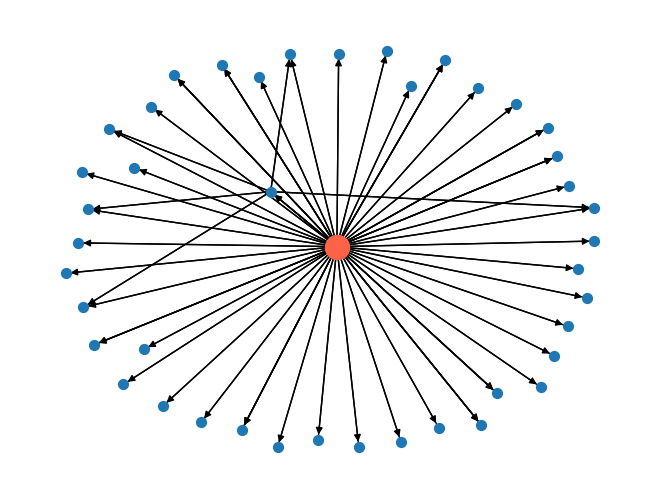

In [20]:
pos = nx.spring_layout(hub_ego)
nx.draw(hub_ego, pos, with_labels=False, node_size=50)
options = {'node_size': 300, 'node_color': 'tomato'}
nx.draw_networkx(hub_ego, pos, nodelist=[largest_hub], **options, with_labels=False, arrows=False)

In [21]:
shortest_paths = pd.DataFrame(nx.shortest_path_length(G, source=largest_hub).values())
alt.Chart(shortest_paths).mark_bar().encode(
    x=alt.X('0:O').title('Shortest Path length'),
    y='count()',
).properties(title='Shortest paths from Sailor Shift')

alt.Chart(...)

In [22]:
shortest_paths = pd.DataFrame(nx.shortest_path_length(G, target=largest_hub).values())
alt.Chart(shortest_paths).mark_bar().encode(
    x=alt.X('0:O').title('Shortest Path length'),
    y='count()',
).properties(title='Shortest paths to Sailor Shift')


alt.Chart(...)

In [23]:
len(nx.shortest_path_length(G.to_undirected(), target=largest_hub))

17277

It looks like only a small proportion of nodes is connected to Sailor Shift by some path, either incoming or outgoing. However, if we consider the undirected version of the graph, almost all nodes are connected to Sailor Shift.

In [24]:
with open('ego.json', 'w') as file:
    json.dump(
        nx.node_link_data(nx.ego_graph(G, largest_hub, radius=7)),
        file,
        )

## Analysis of nodes

In [25]:
from collections import Counter

In [26]:
nodes = G.nodes(data=True)
c = Counter([data.get('Node Type') for node, data in nodes])
node_types = pd.DataFrame(c.most_common())
node_types

,0,1
0,Person,11361
1,Song,3615
2,RecordLabel,1217
3,Album,996
4,MusicalGroup,223


In [27]:
alt.Chart(node_types).mark_bar().encode(
    x=alt.X('1:Q').title('# of nodes'),
    y=alt.Y('0:N').title('Node type').sort('-x'),
    color=alt.Color('0:N', legend=None).sort('-x'),
    tooltip='1:Q',
)

alt.Chart(...)

### Songs and Albums

In [28]:
songs_and_albums = filter(lambda x : x[1].get('Node Type') in ('Song', 'Album'), G.nodes(data=True))
songs_and_albums = pd.DataFrame([{'id': node, **data}
                      for node, data in songs_and_albums])
songs_and_albums.head()

,id,Node Type,name,single,release_date,genre,notable,written_date,notoriety_date
0,0,Song,Breaking These Chains,True,2017,Oceanus Folk,True,NaN,NaN
1,5,Song,Unshackled Heart,False,2026,Lo-Fi Electronica,True,NaN,NaN
2,10,Song,No Limits Left,True,2020,Indie Folk,True,2020,NaN
3,15,Song,Sovereign Soul,True,2027,Darkwave,False,NaN,NaN
4,26,Song,"Clean Lungs, Clear Mind",False,2022,Speed Metal,True,NaN,NaN


In [29]:
songs_and_albums['of'] = songs_and_albums.genre == 'Oceanus Folk'

select = alt.selection_interval()

timeline = alt.Chart(songs_and_albums).mark_area().encode(
    x=alt.X('release_date:T').title('Release date'),
    y=alt.Y('count()').title('Number of songs'),
    color=alt.Color('of', legend=None),
).add_params(
    select,
).properties(
    width=600,
)

genres = alt.Chart(songs_and_albums).mark_bar().encode(
    y=alt.Y('count()').title('Number of songs'),
    x=alt.Y('genre:N').sort('-y').title('Genre'),
    color='of',
).transform_filter(
    select,
).properties(
    width=600,
)

timeline & genres

alt.VConcatChart(...)

We export the subgraph induced from nodes of type song and album for further analysis of influence between genres.

In [30]:
influence_graph = G.subgraph(songs_and_albums.id).copy()
print(influence_graph)

MultiDiGraph with 4611 nodes and 7340 edges


In [31]:
for node in influence_graph.nodes:
    influence_graph.nodes[node]['Node Type'] = influence_graph.nodes[node].get('genre', 'Unknown')

In [32]:
with open('influence.json', 'w') as file:
    json.dump(nx.node_link_data(influence_graph), file)

## Collaboration network

We create a collaboration network (co-composers) from the projection on Persons and Musical group of the bipartite graph induced from edges with edge type `ComposerOf`.

We export this collaboration network in a format suitable for analysis with our graphical interface.

In [33]:
def filter_edge(u, v, key):
    return G[u][v][key].get('Edge Type') == 'ComposerOf'

bip_graph = nx.subgraph_view(G, filter_edge=filter_edge)
bip_graph = nx.edge_subgraph(bip_graph, edges=bip_graph.edges)

bip_graph = nx.Graph(bip_graph)
print(bip_graph)

Graph with 5488 nodes and 3290 edges


In [34]:
from networkx.algorithms import bipartite

In [35]:
bipartite.is_bipartite(bip_graph)

True

In [36]:
nodes = [
    node
    for node in bip_graph.nodes
    if bip_graph.nodes[node]['Node Type'] in ('Person', 'MusicalGroup')
]
collaboration = bipartite.projected_graph(
    bip_graph, nodes,
)
print(collaboration)

Graph with 2545 nodes and 317 edges


In [37]:
with open('collaboration.json', 'w') as file:
    json.dump(nx.node_link_data(collaboration), file)